In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [24]:
df = pd.read_csv("../data/audio_features.csv")

## Map confidence & difficulty levels to 3 classes

In [25]:
def map_levels(x):
    if x in [1, 2]:
        return "low"
    elif x == 3:
        return "medium"
    elif x in [4, 5]:
        return "high"

In [26]:
df["confidence_level"] = df["confidence"].apply(map_levels)
df["difficulty_level"] = df["difficulty"].apply(map_levels)

## Inspect Box Plots

In [35]:
exclude_cols = ["clue_id", "confidence", "difficulty", "confidence_level", "difficulty_level", "transcript", "Spymaster ID"]
features = [c for c in df.columns if c not in exclude_cols]

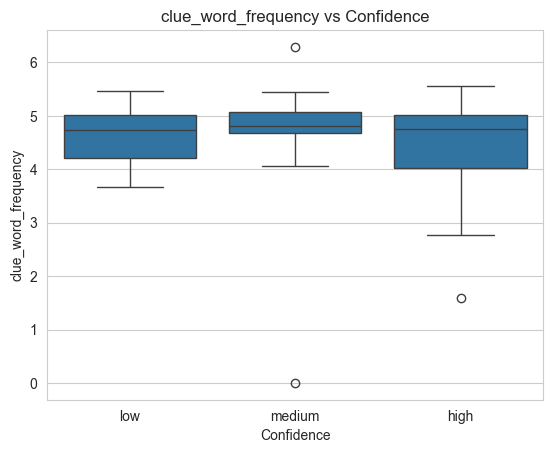

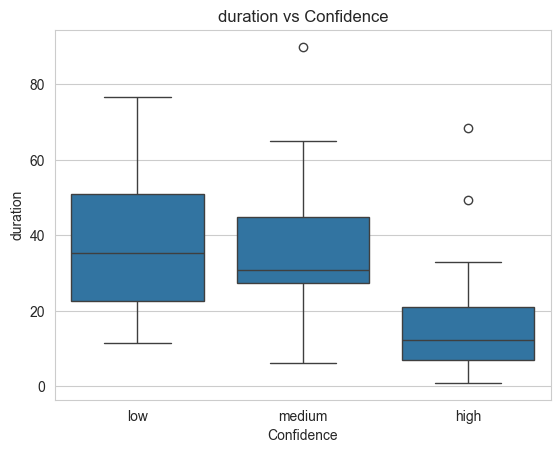

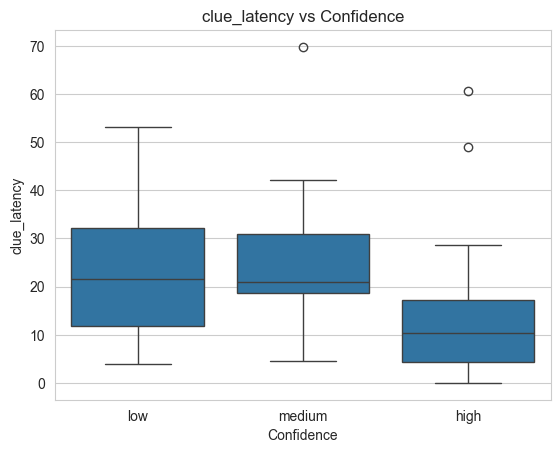

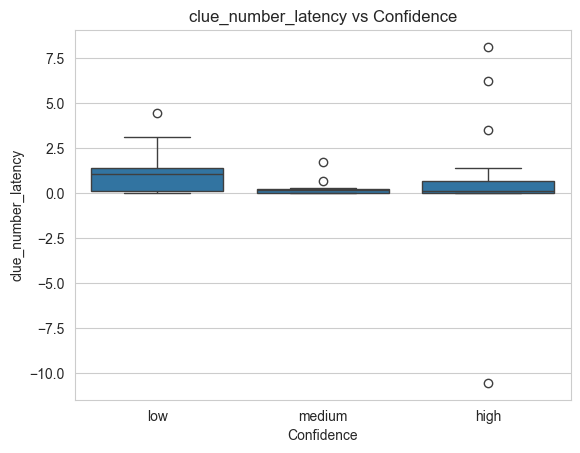

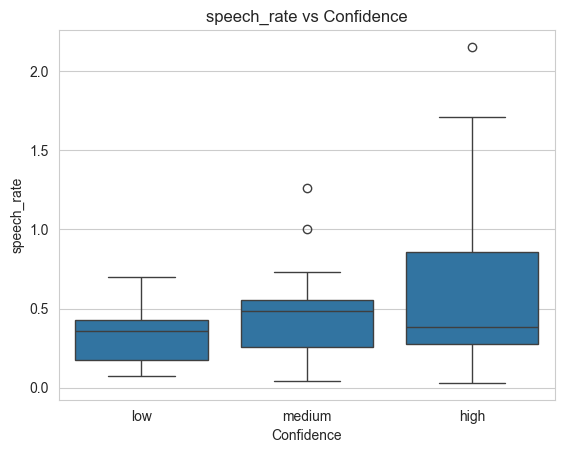

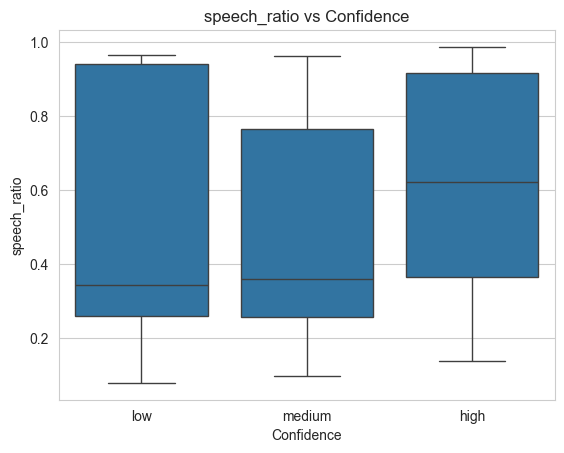

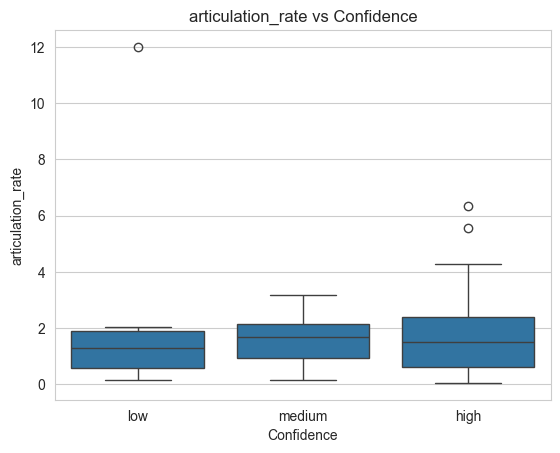

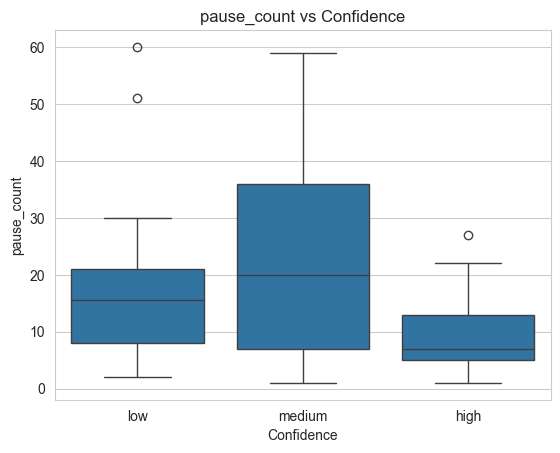

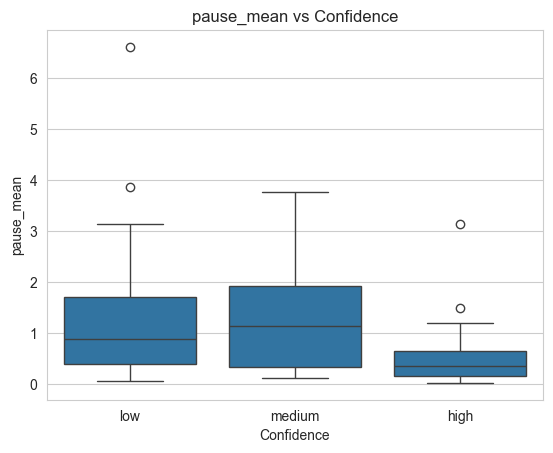

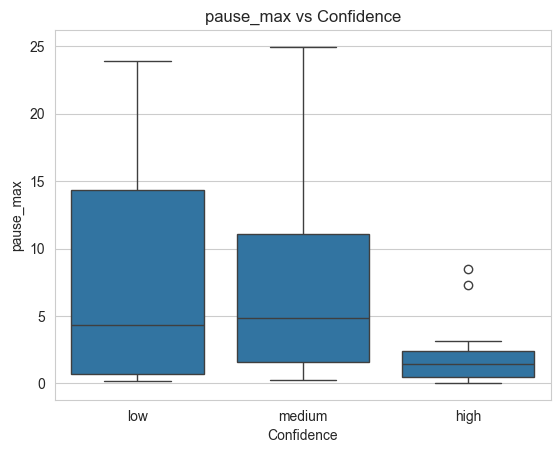

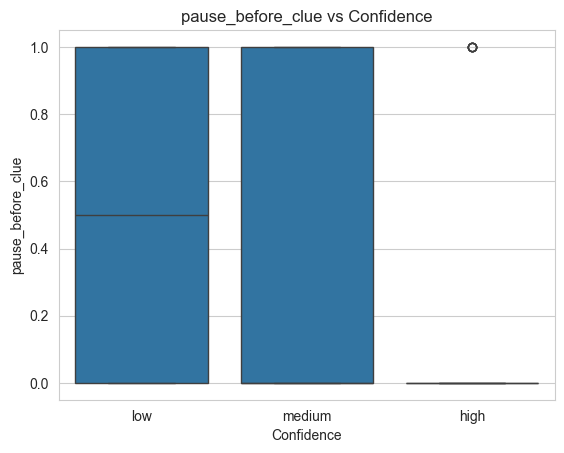

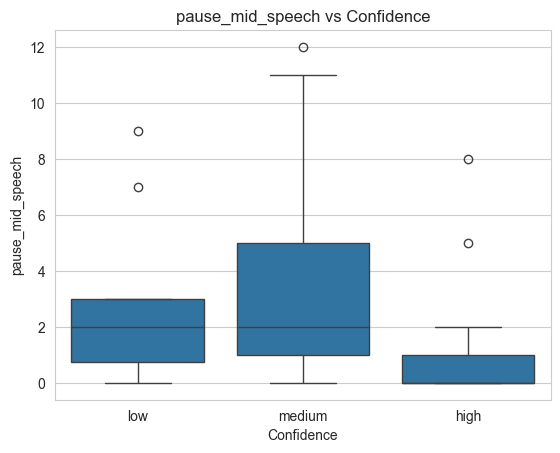

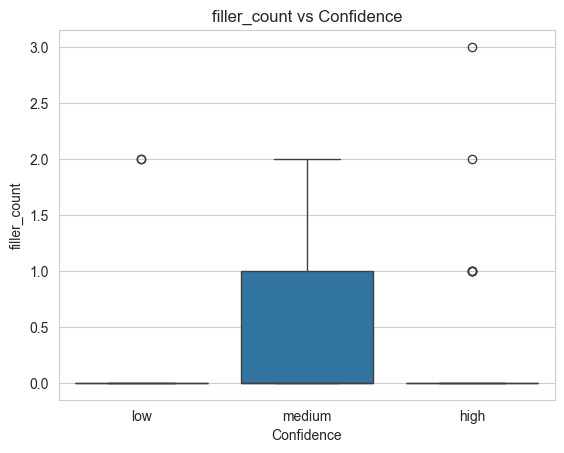

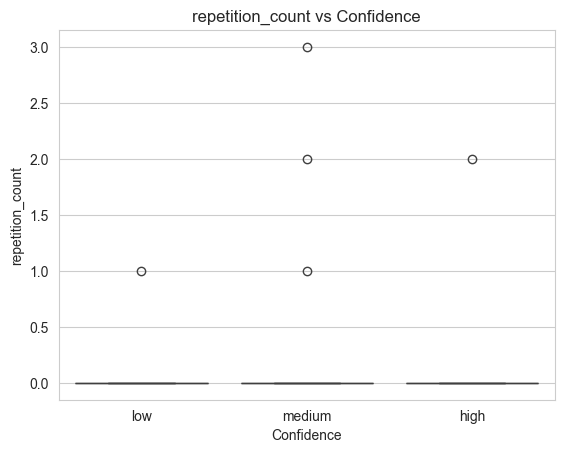

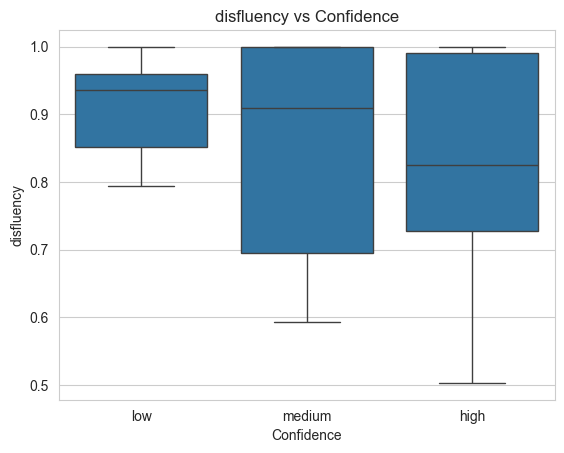

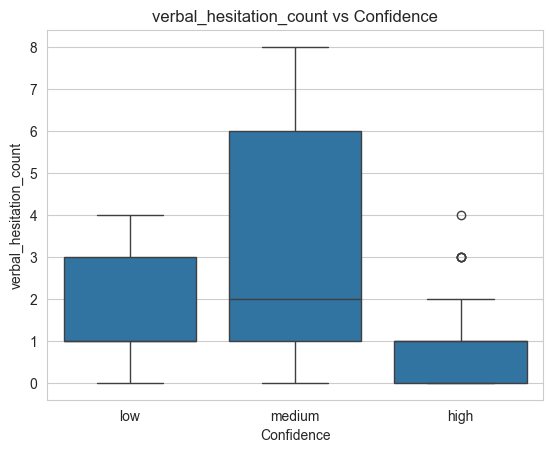

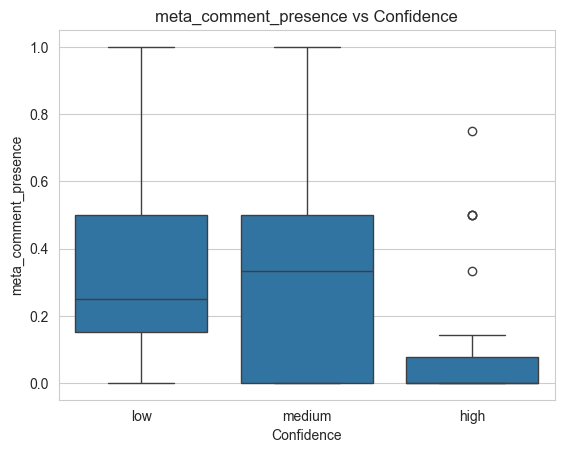

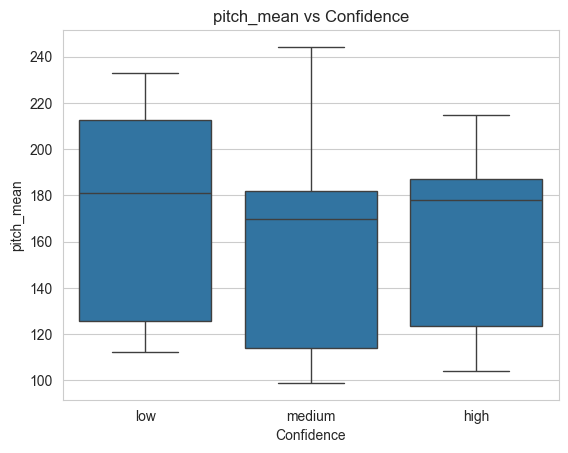

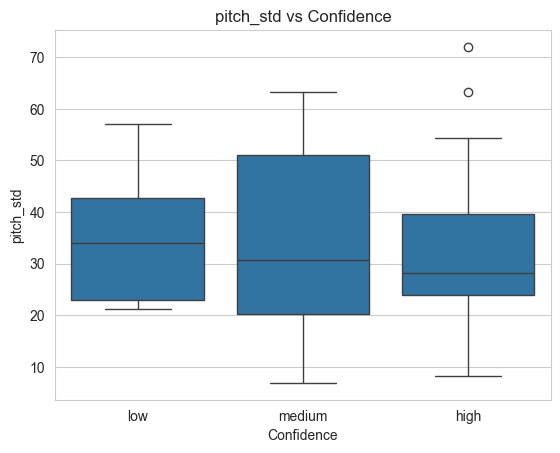

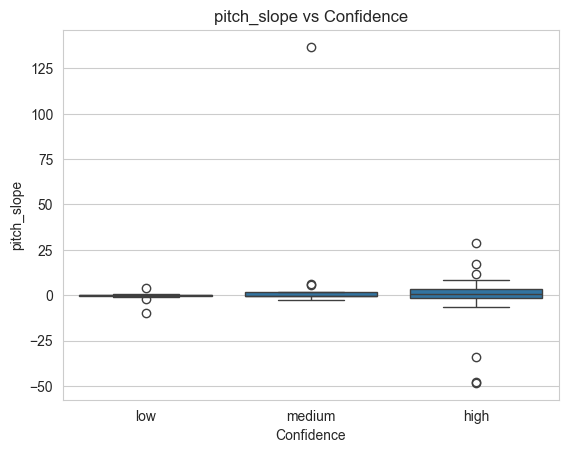

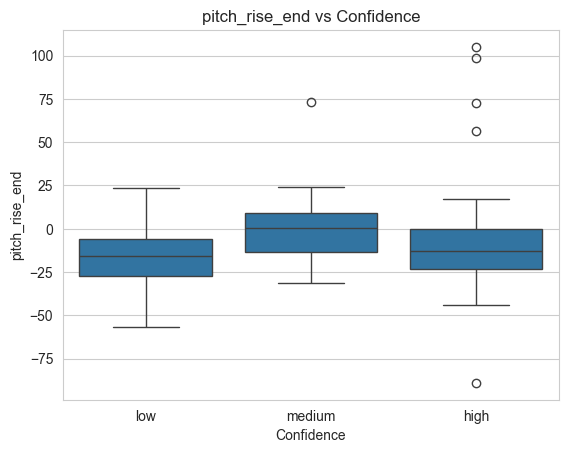

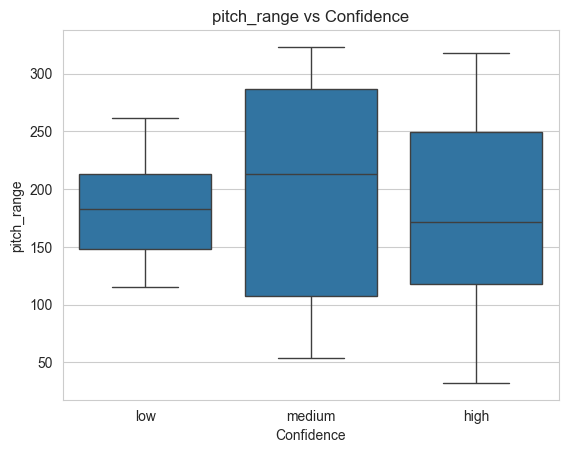

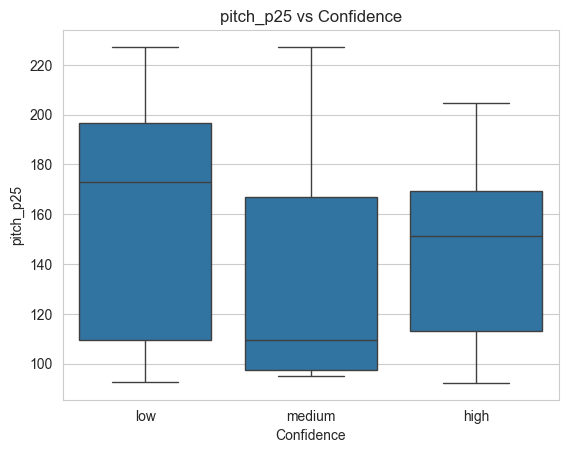

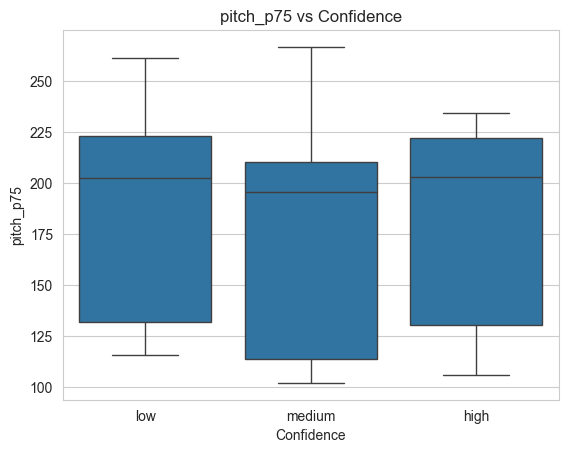

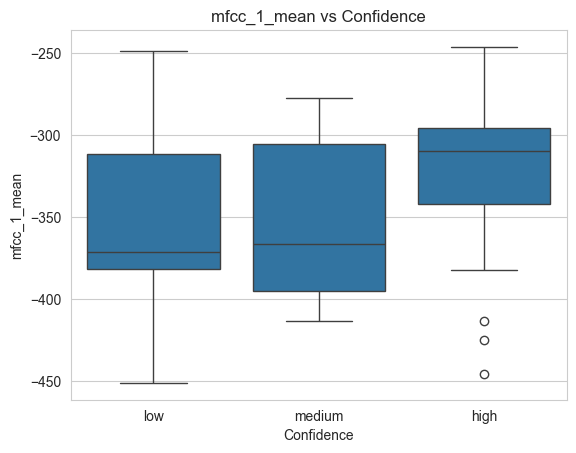

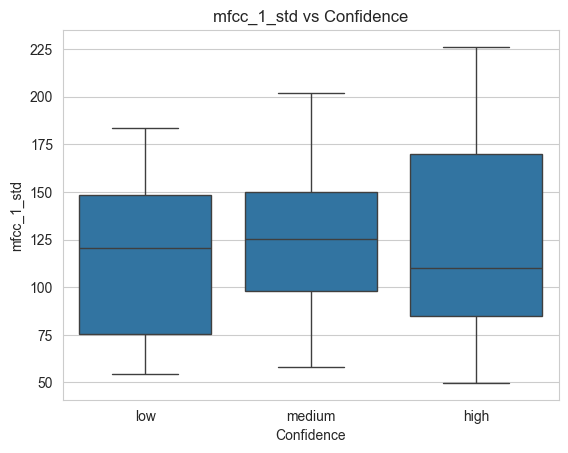

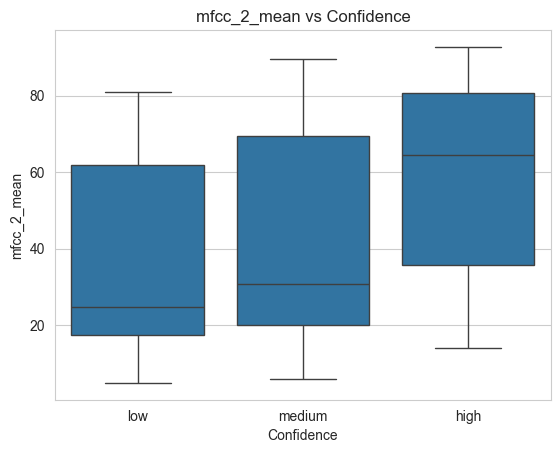

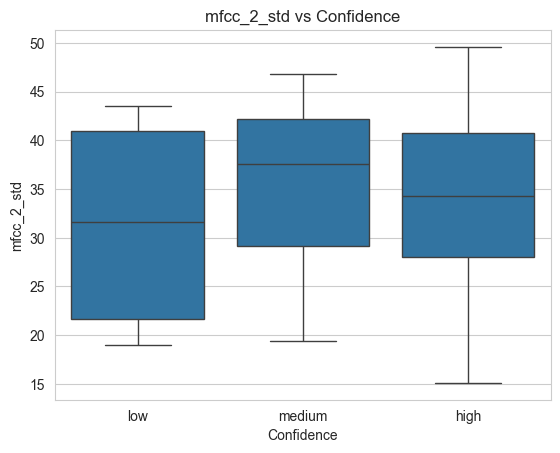

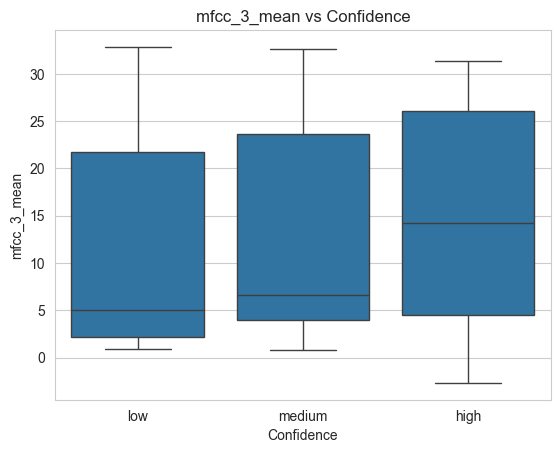

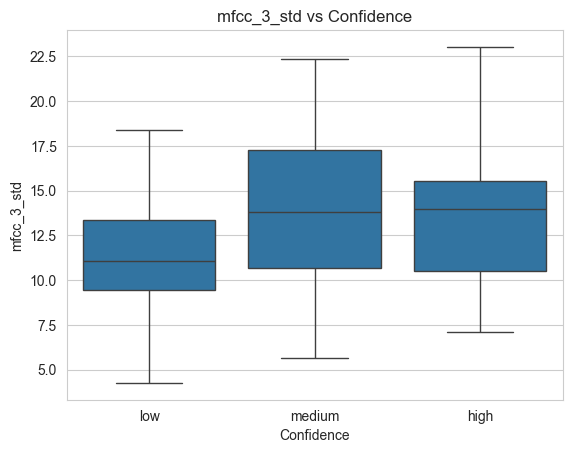

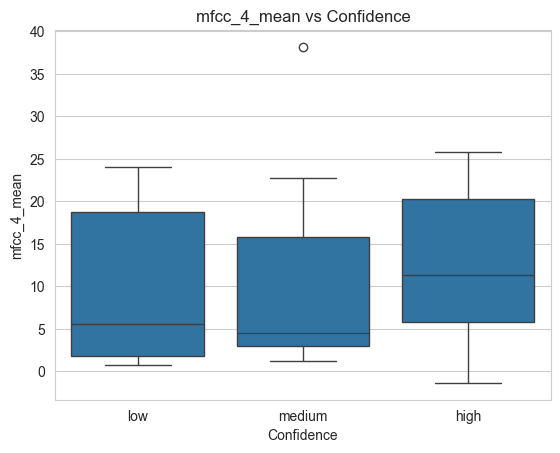

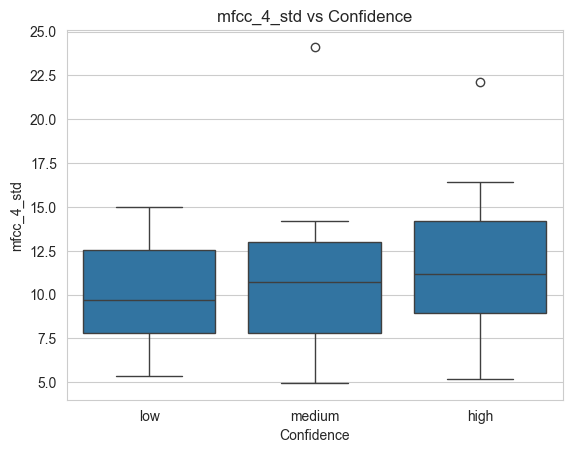

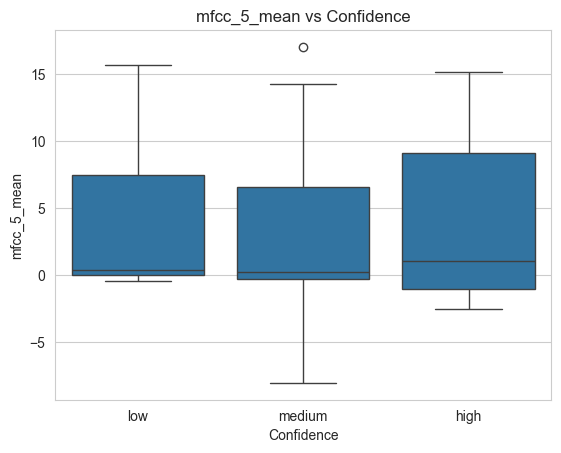

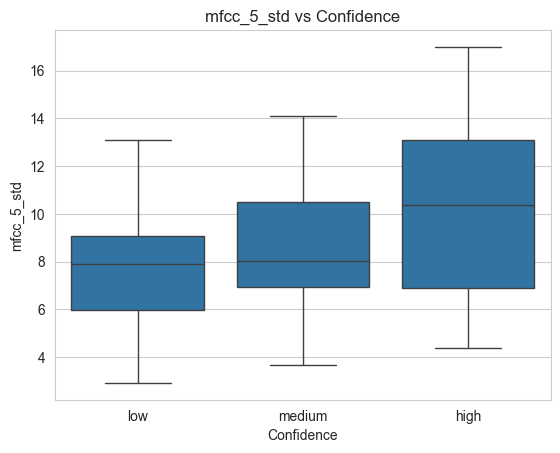

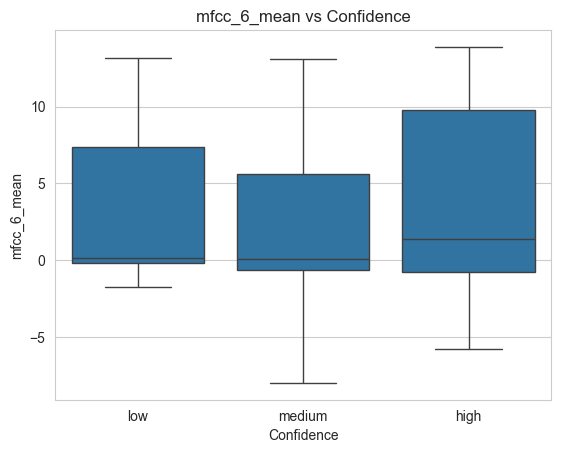

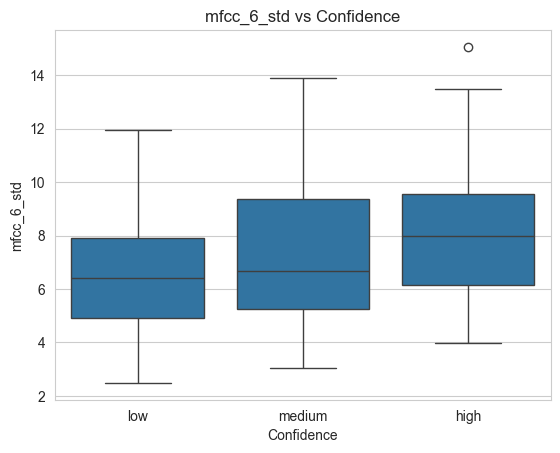

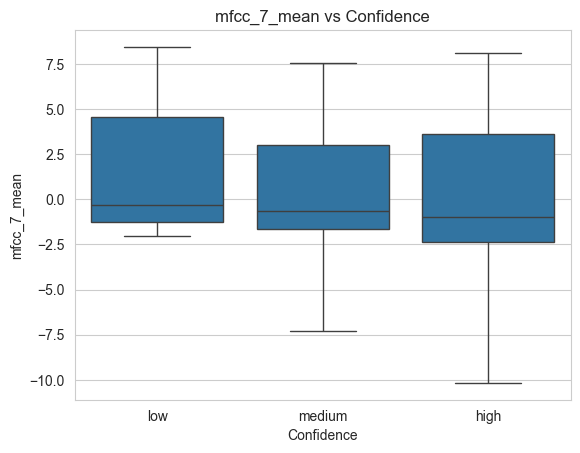

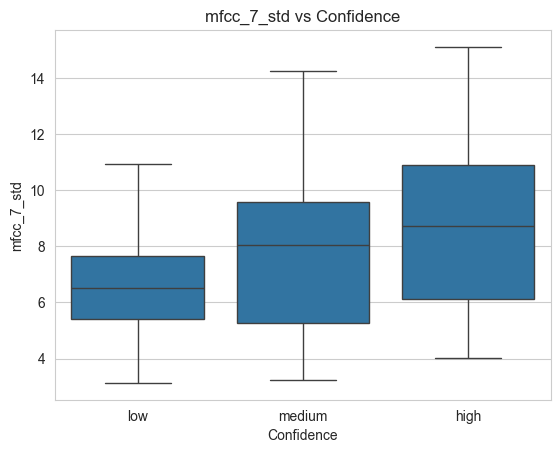

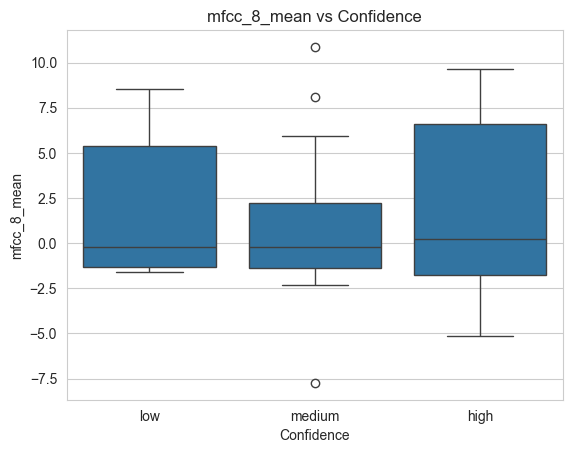

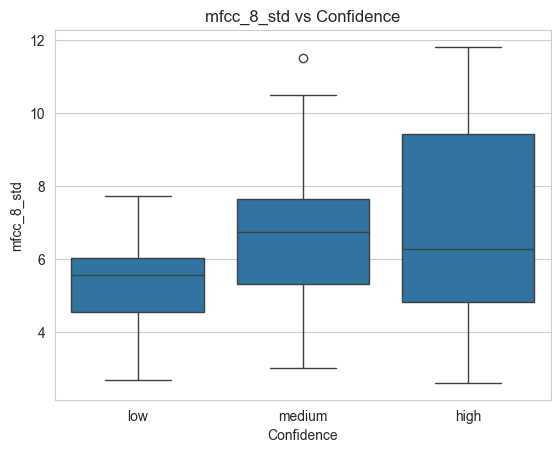

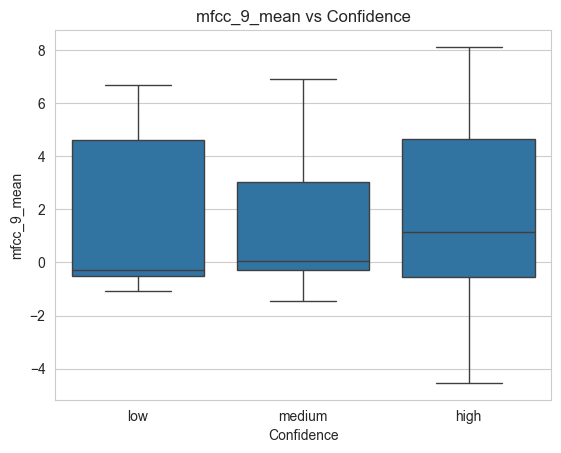

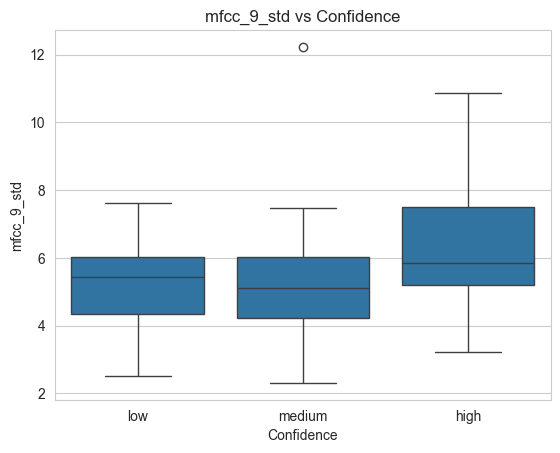

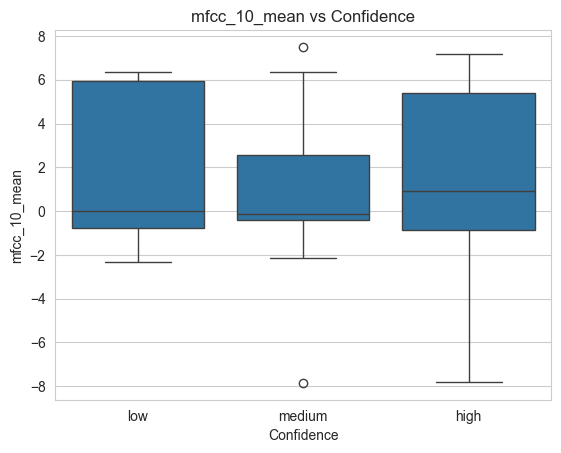

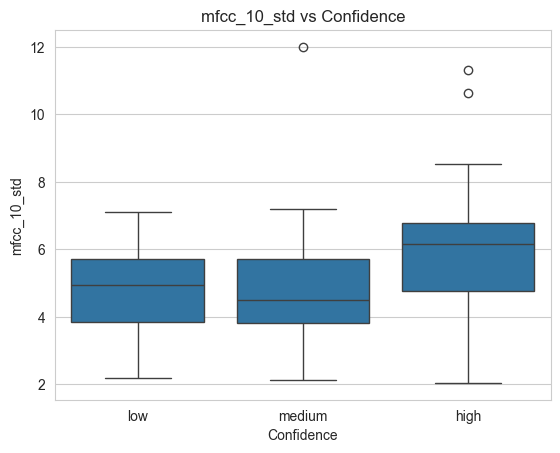

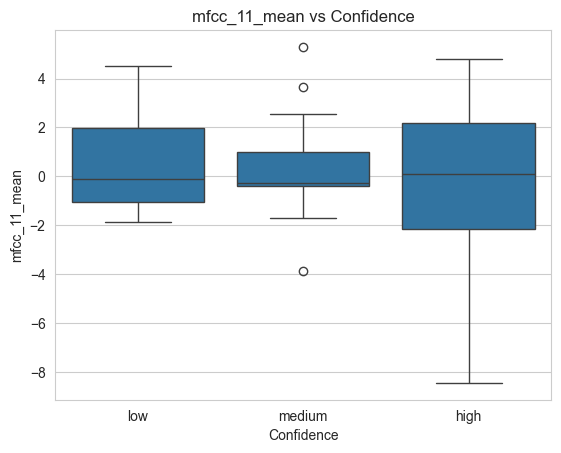

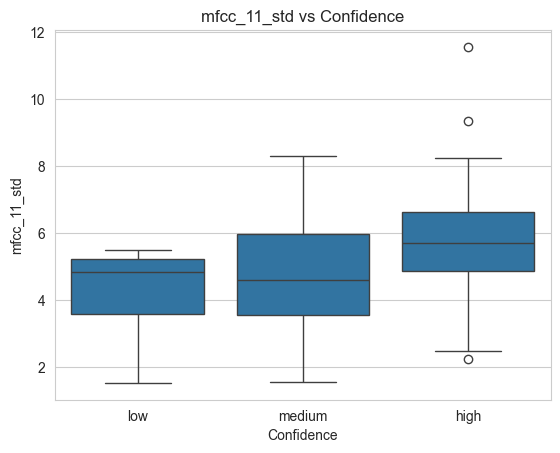

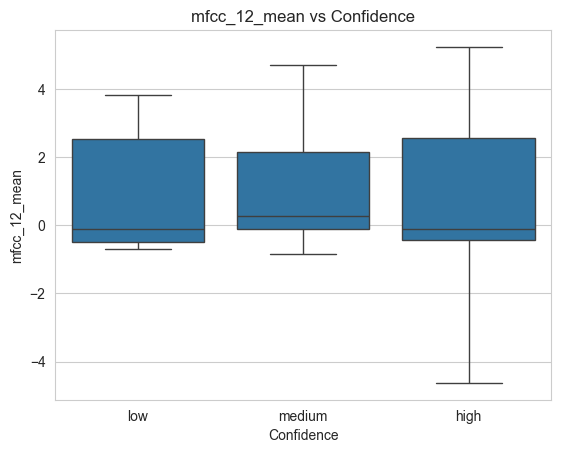

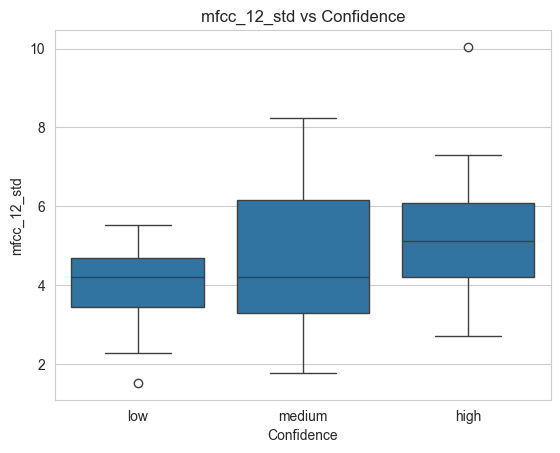

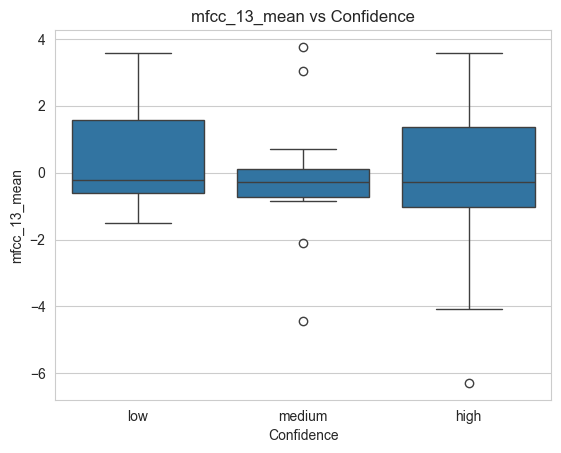

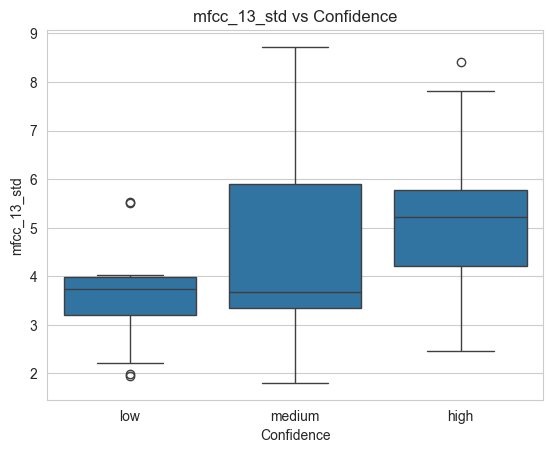

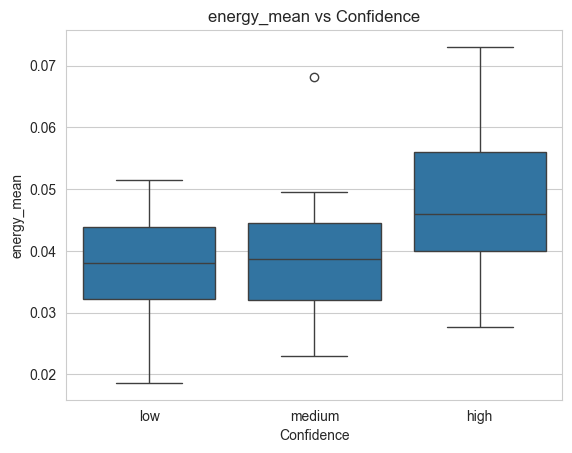

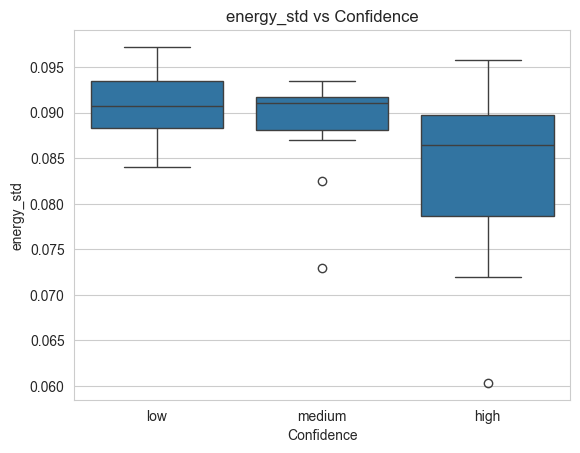

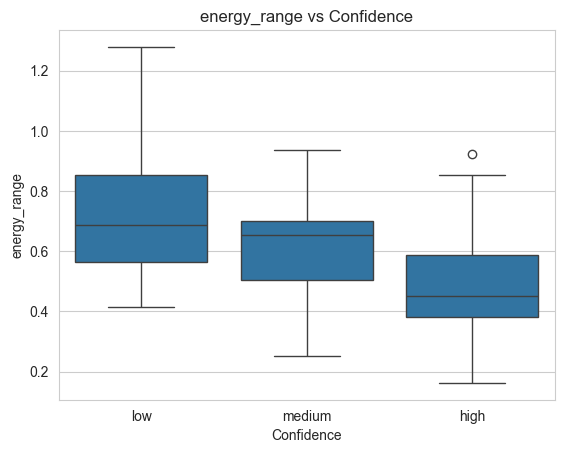

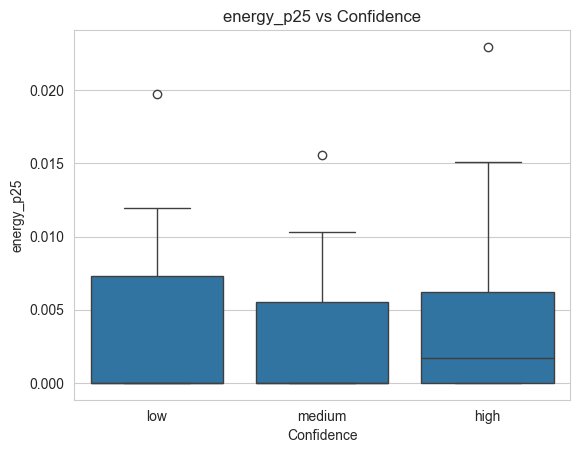

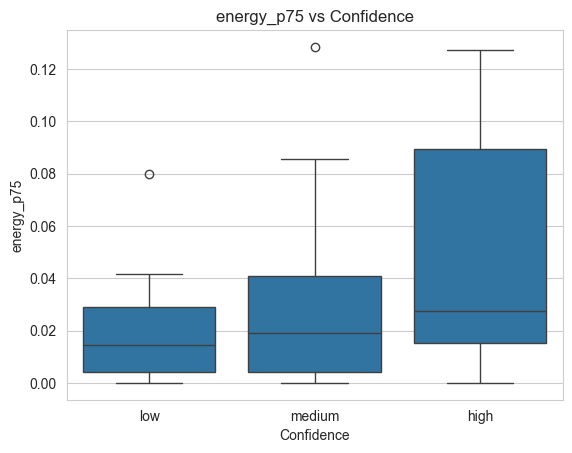

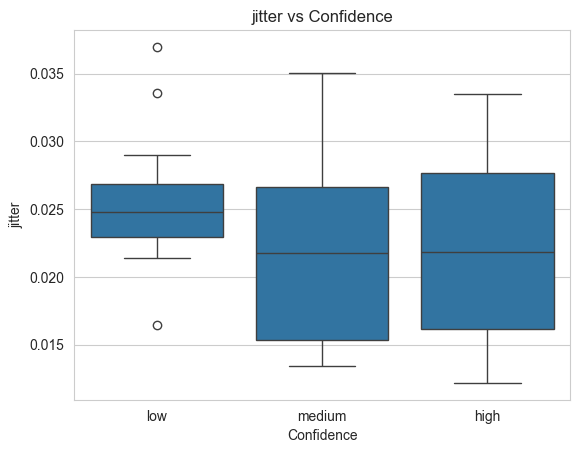

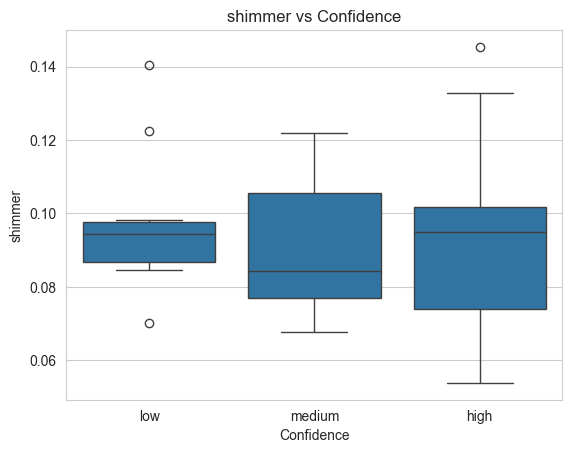

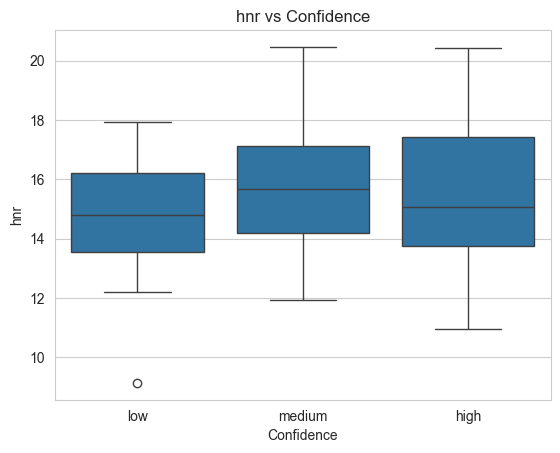

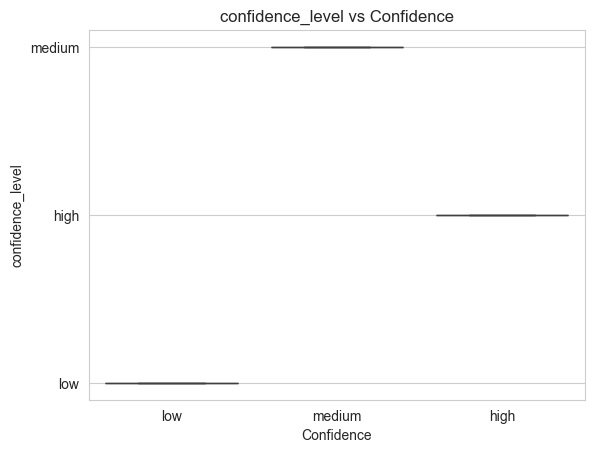

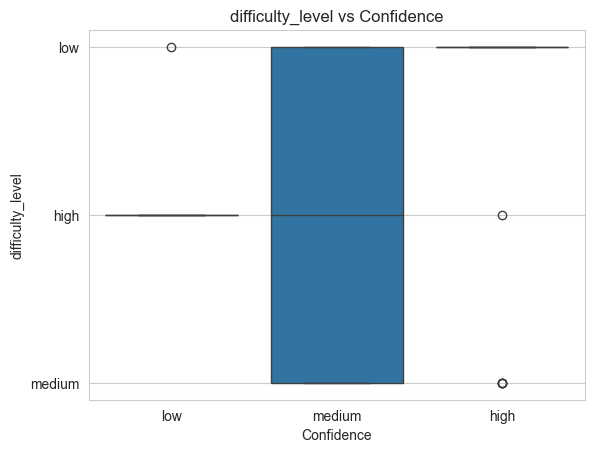

In [7]:
for feature in features:
    plt.figure()
    sns.boxplot(x="confidence_level", y=feature, data=df, order = ["low", "medium", "high"])
    plt.title(f"{feature} vs Confidence")
    plt.xlabel("Confidence")
    plt.ylabel(feature)
    plt.show()

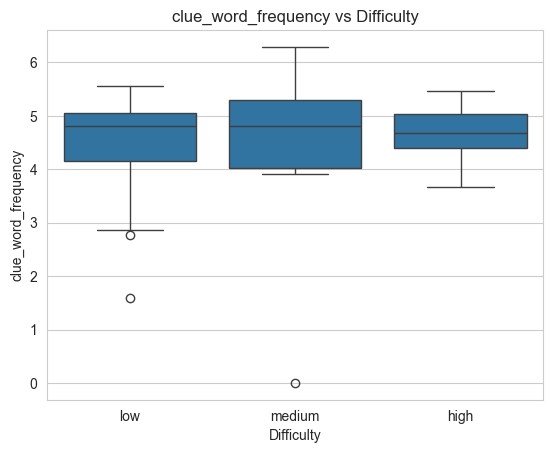

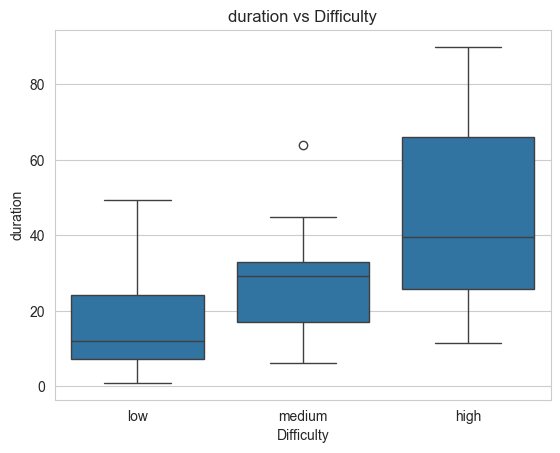

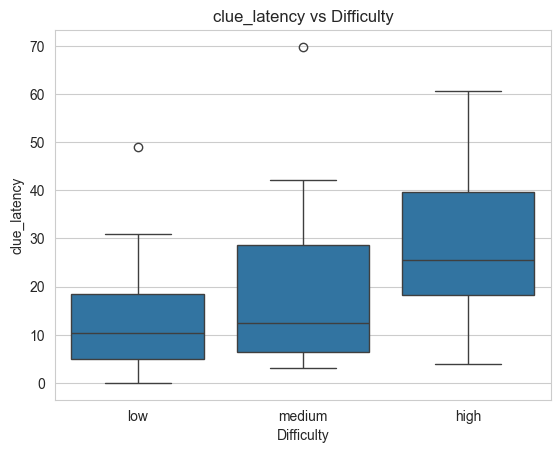

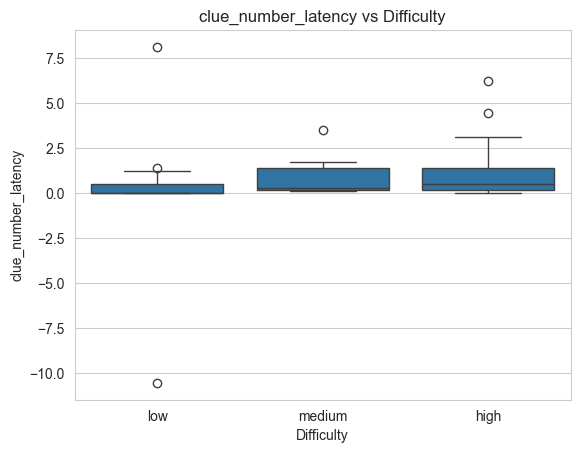

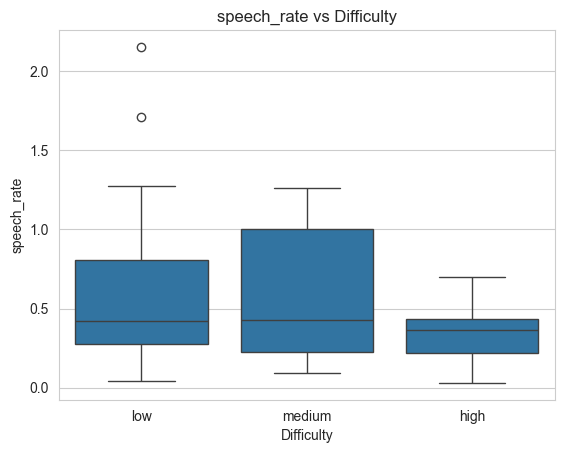

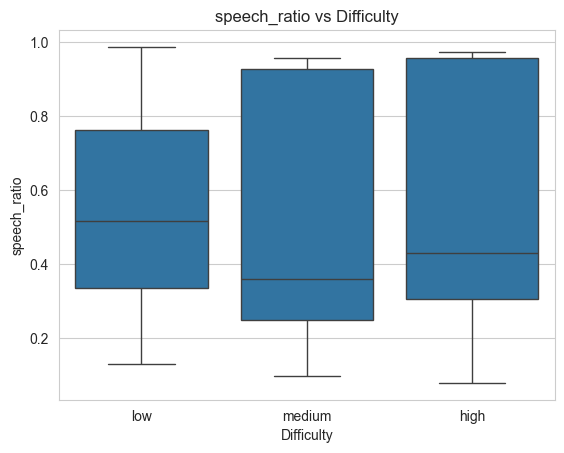

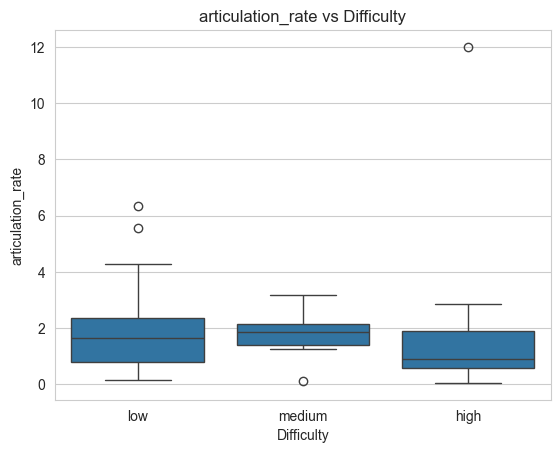

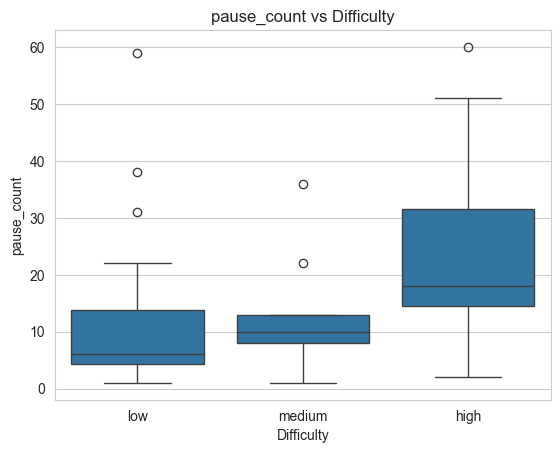

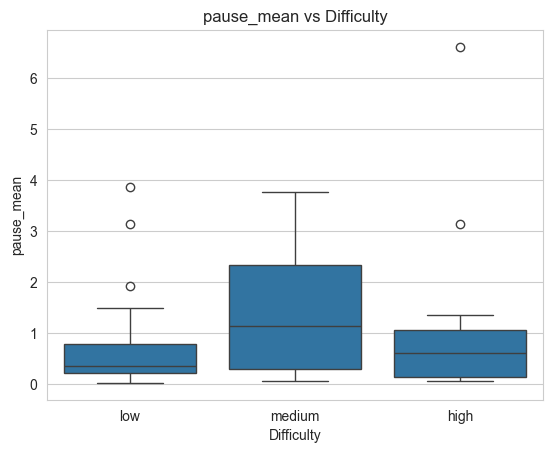

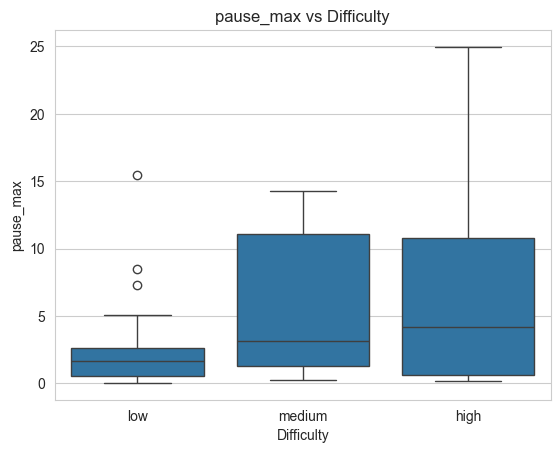

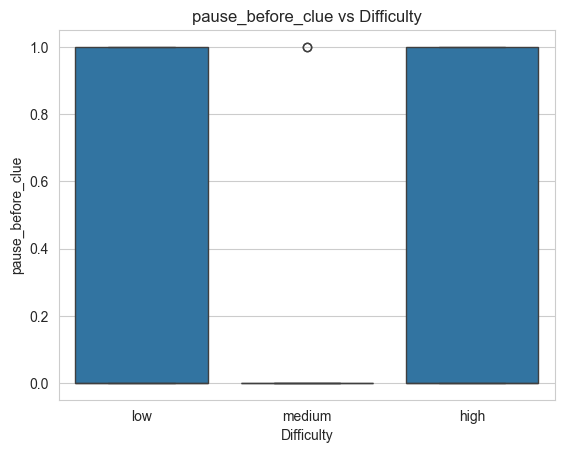

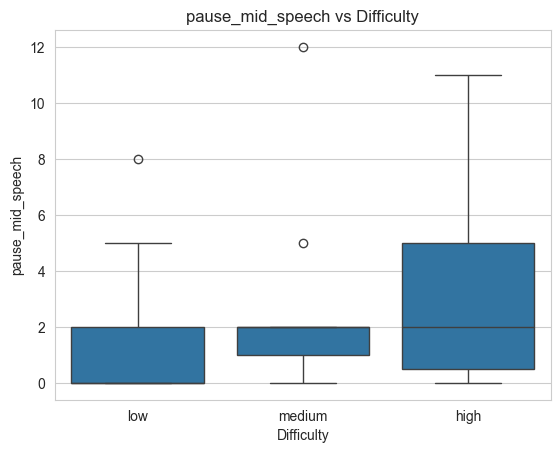

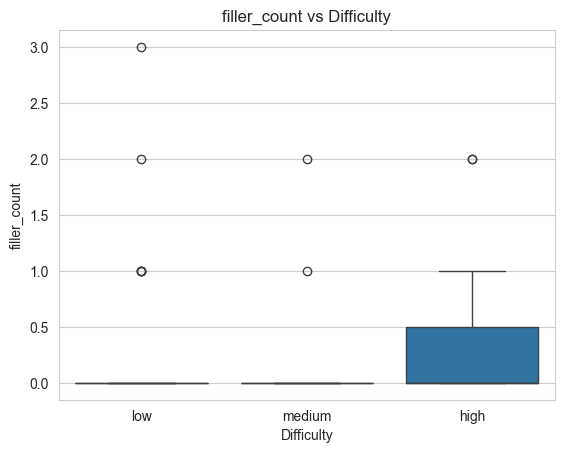

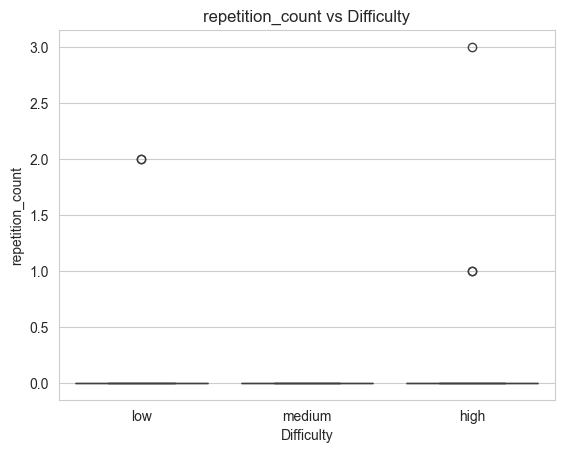

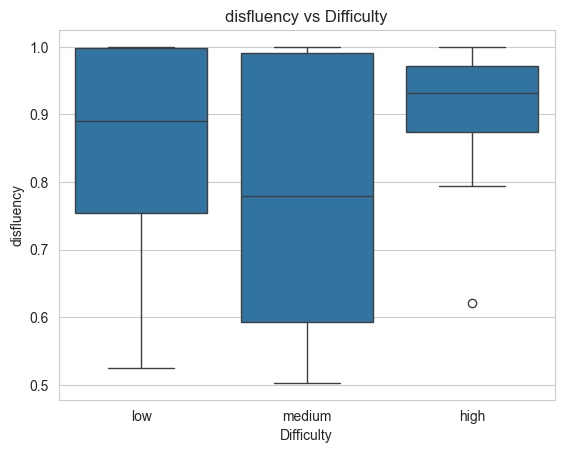

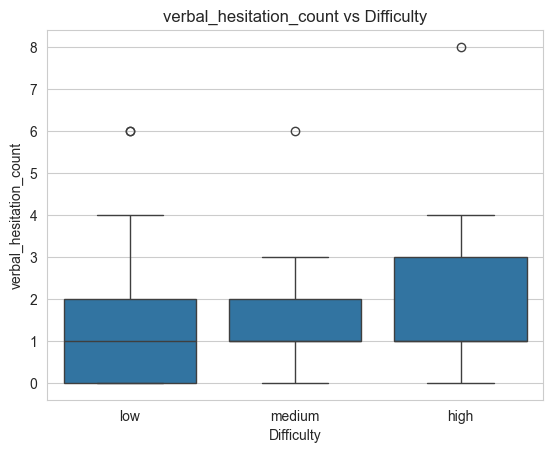

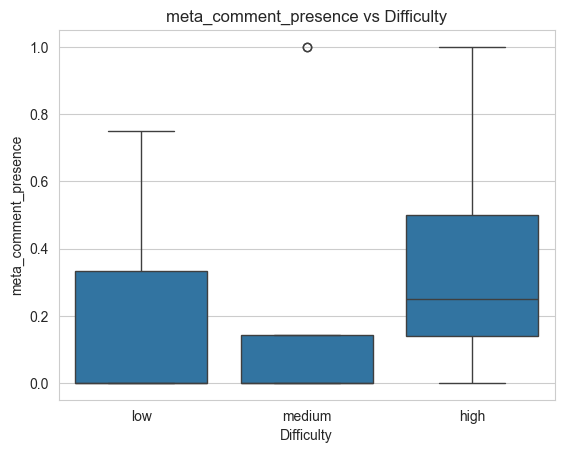

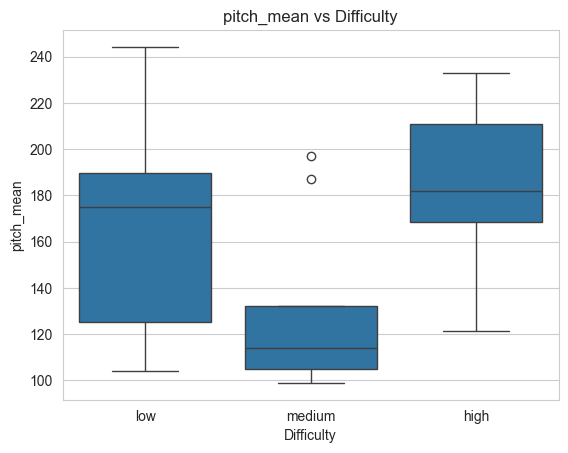

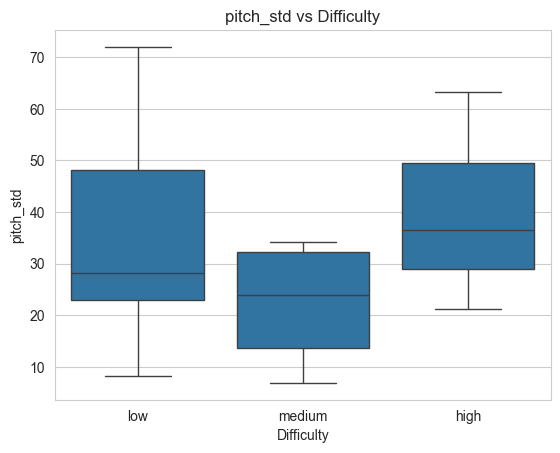

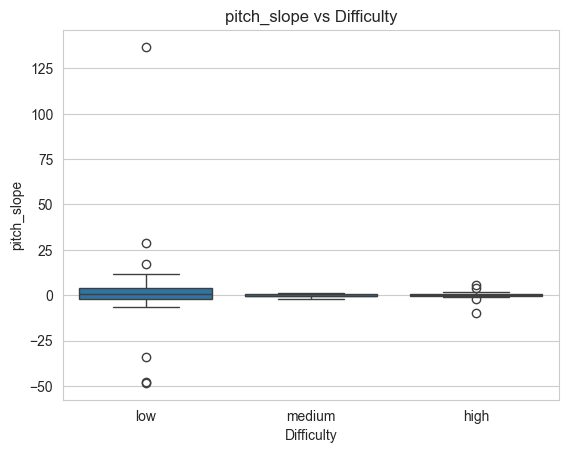

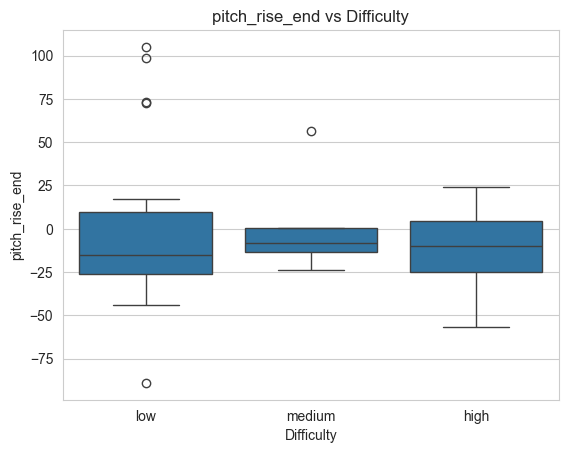

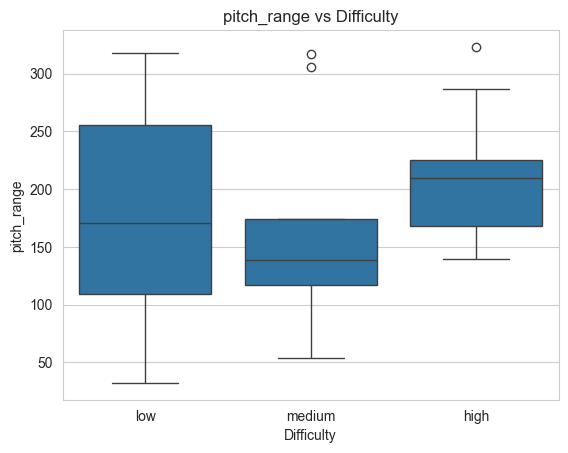

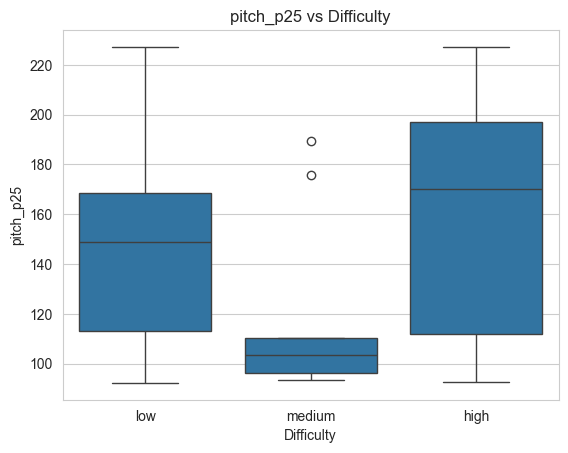

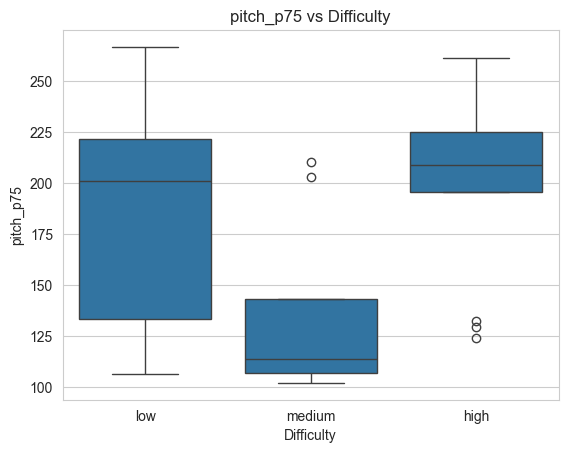

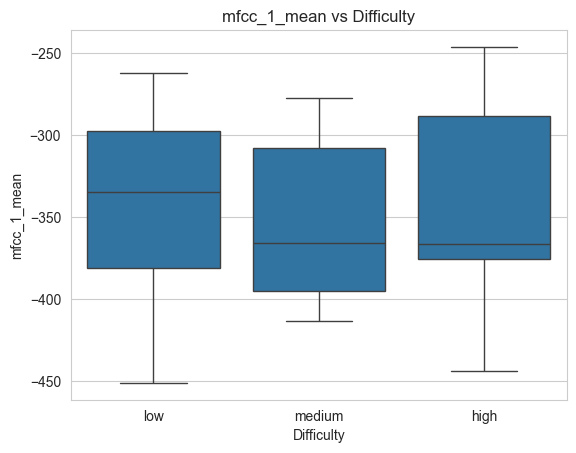

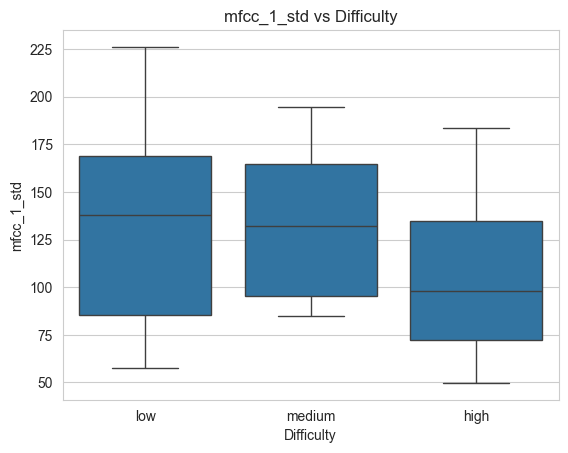

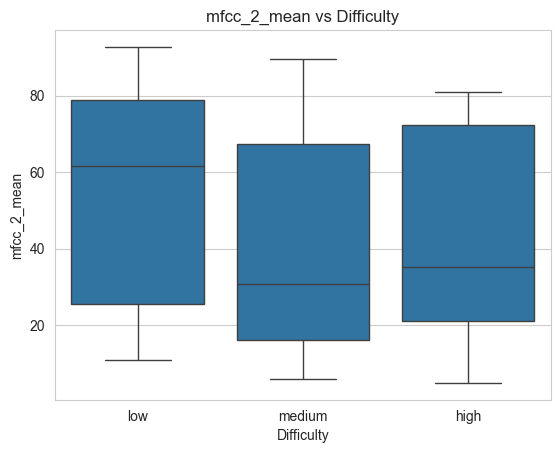

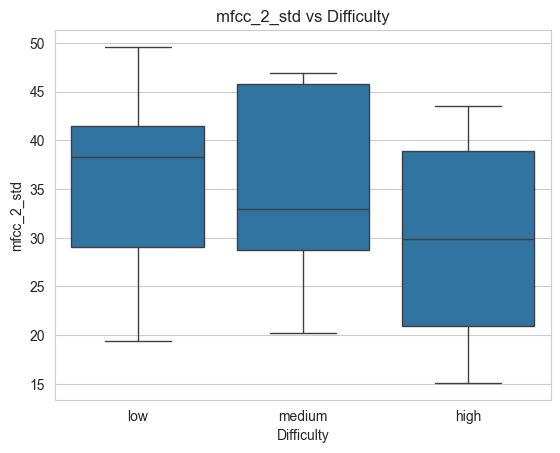

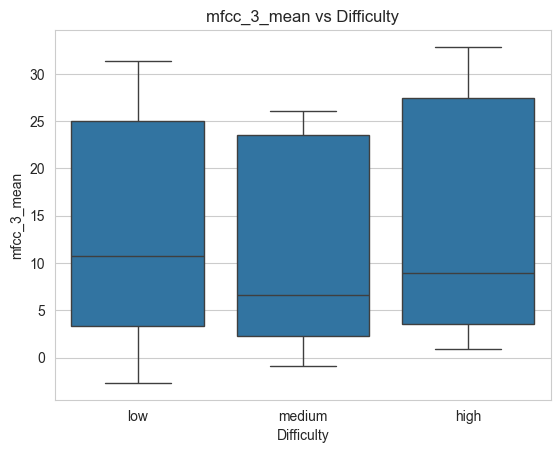

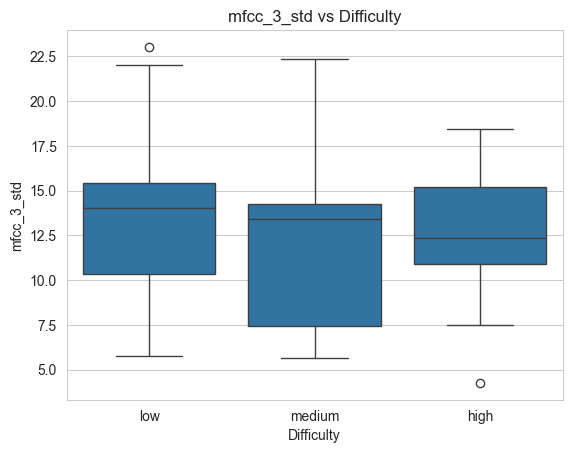

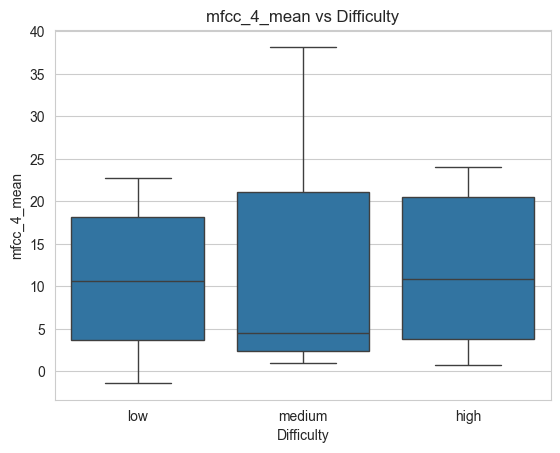

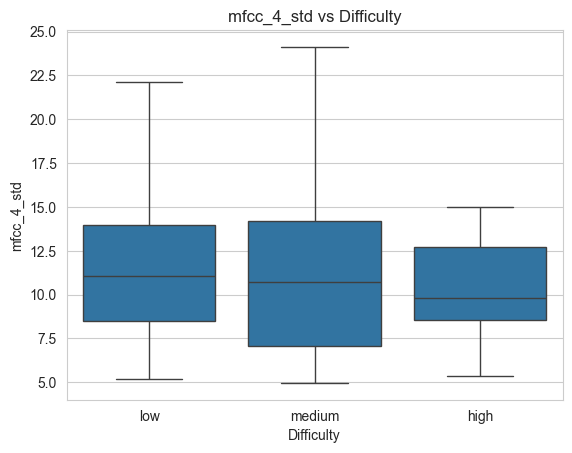

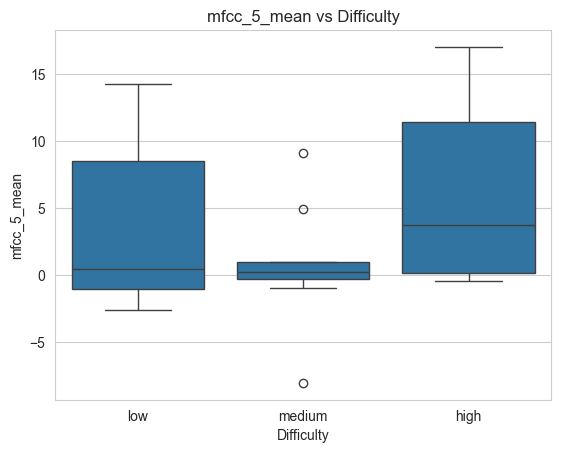

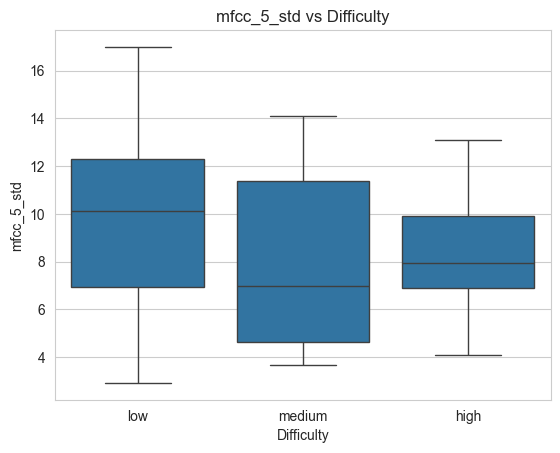

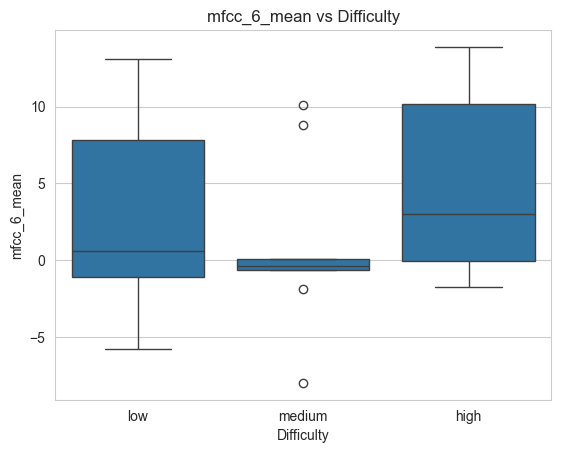

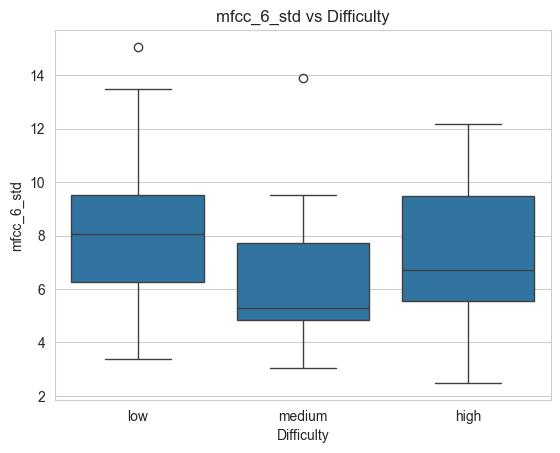

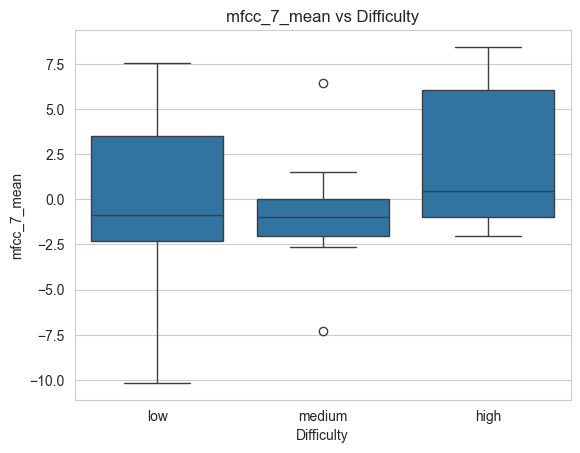

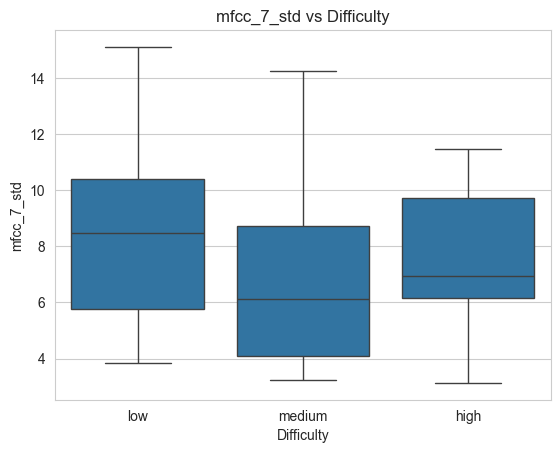

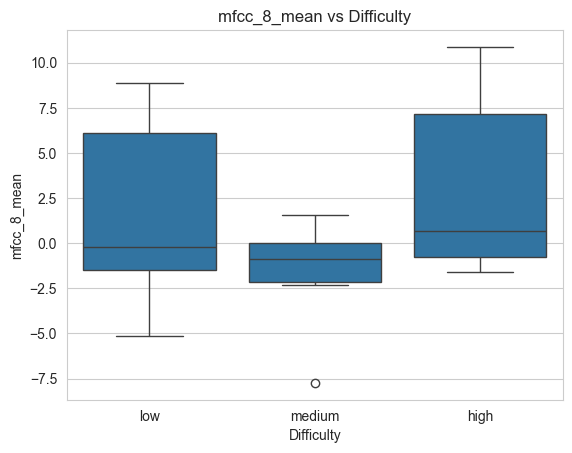

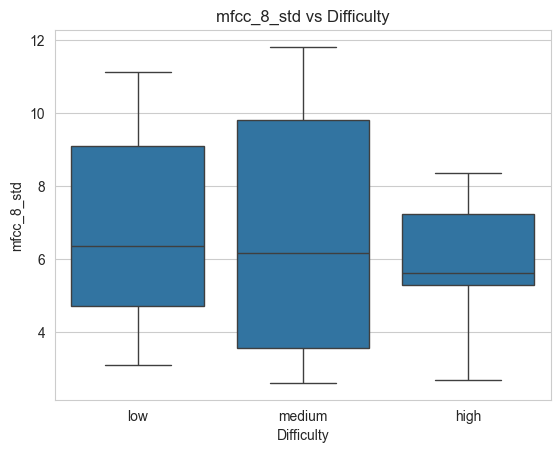

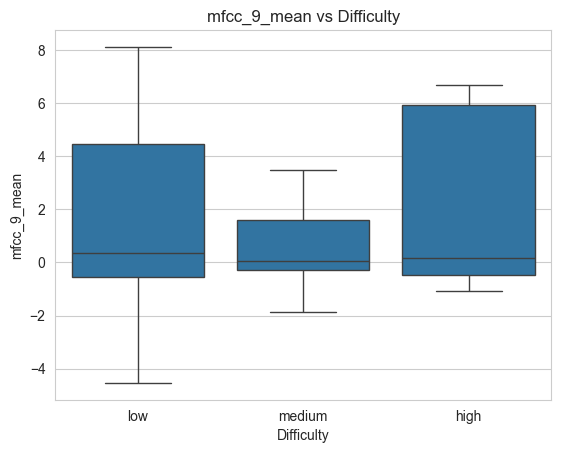

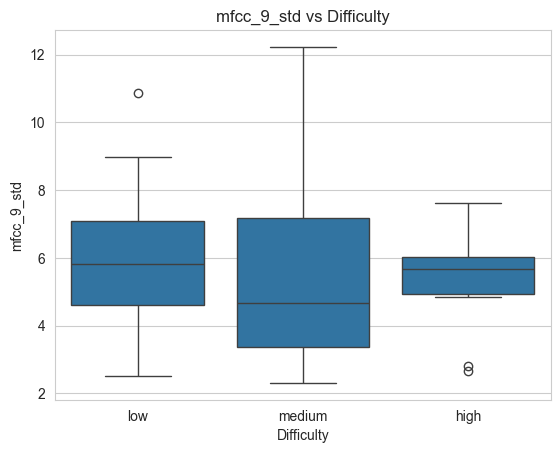

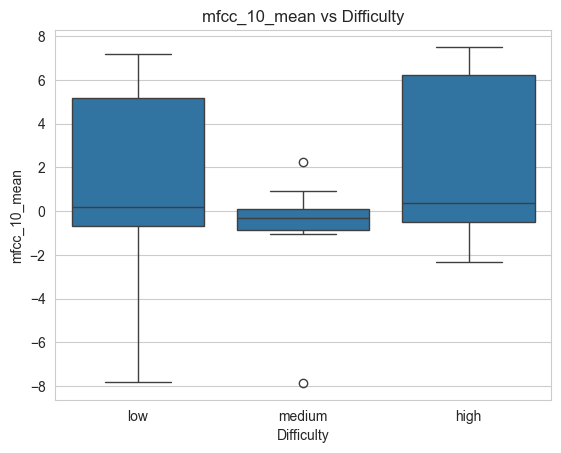

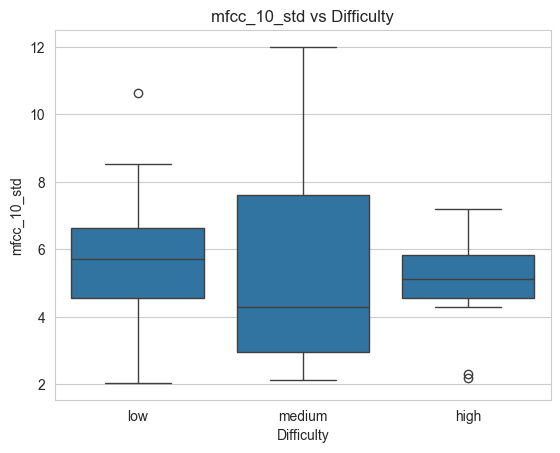

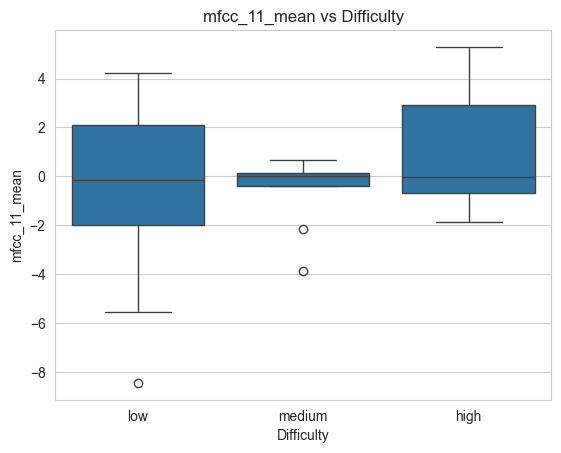

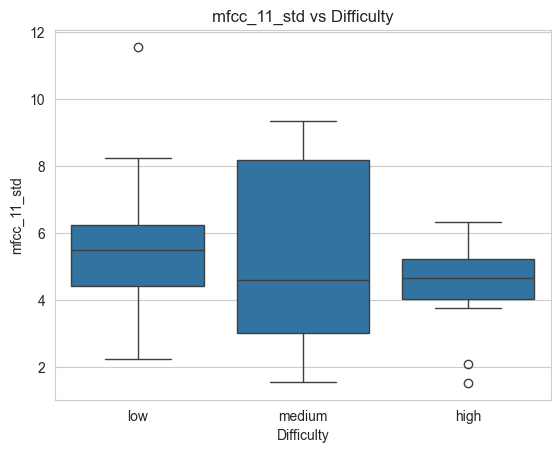

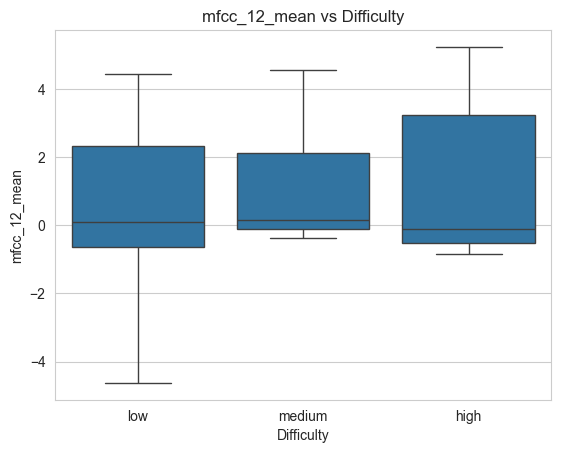

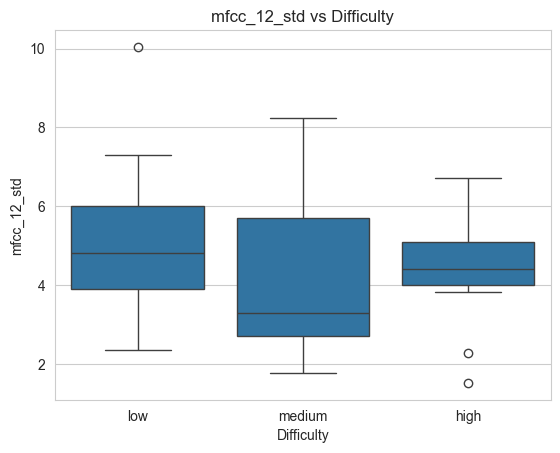

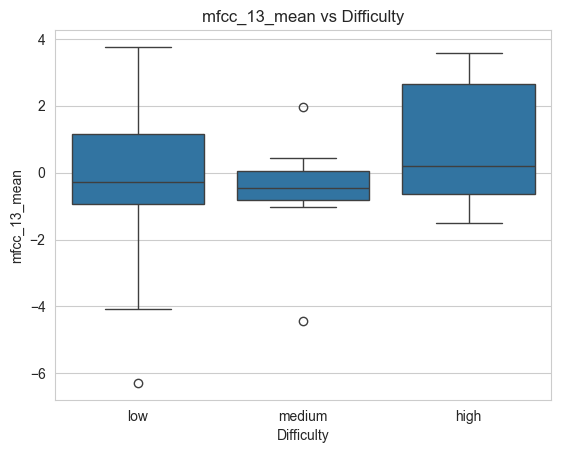

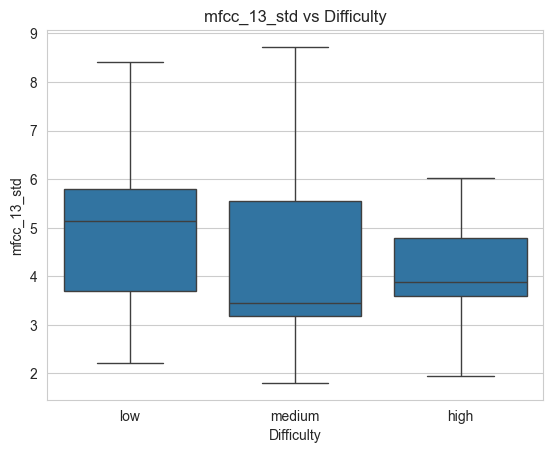

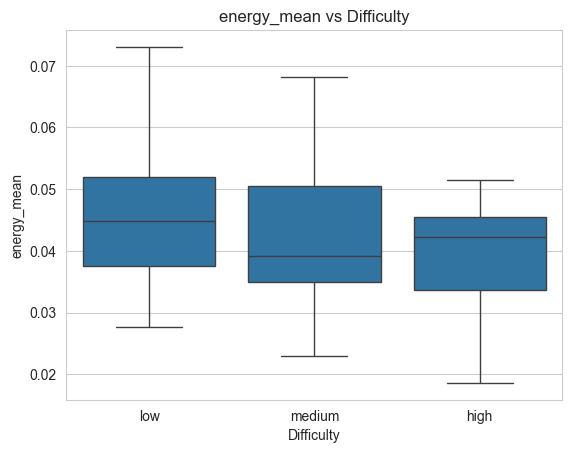

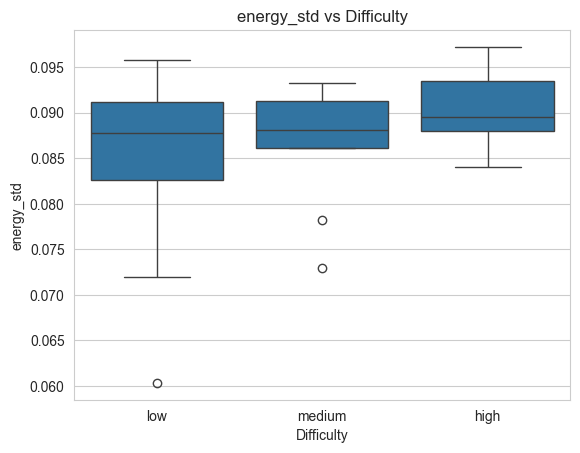

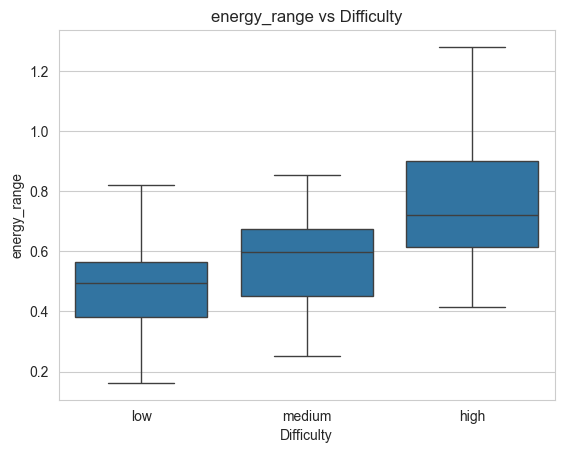

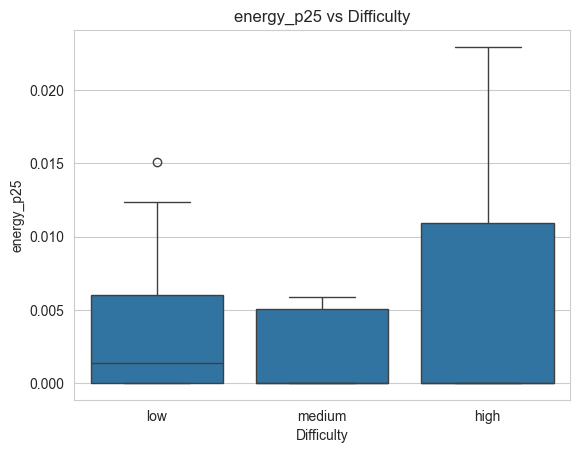

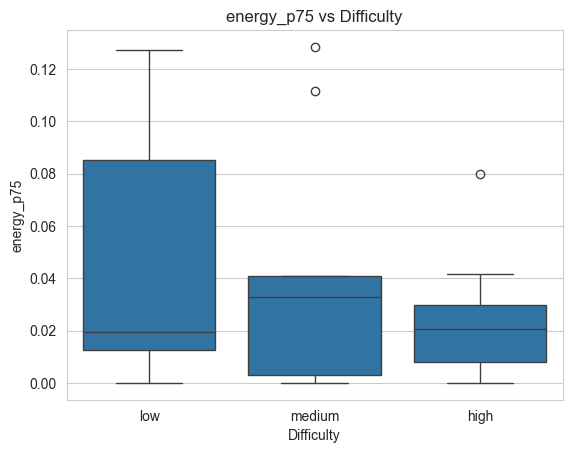

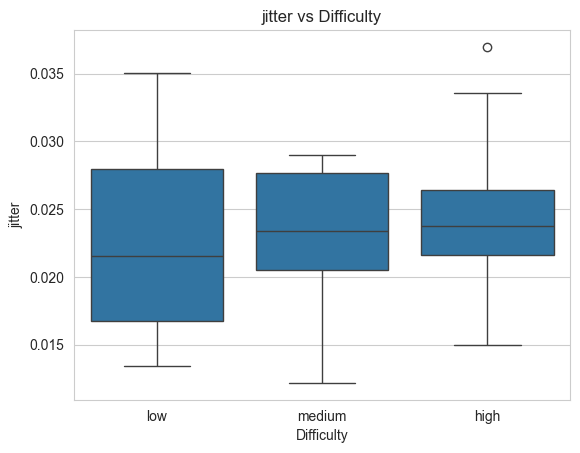

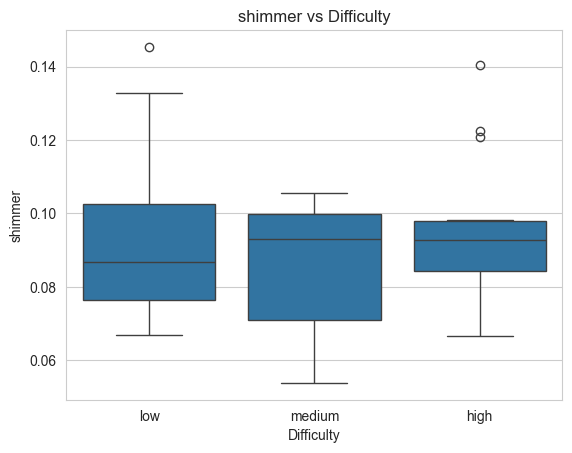

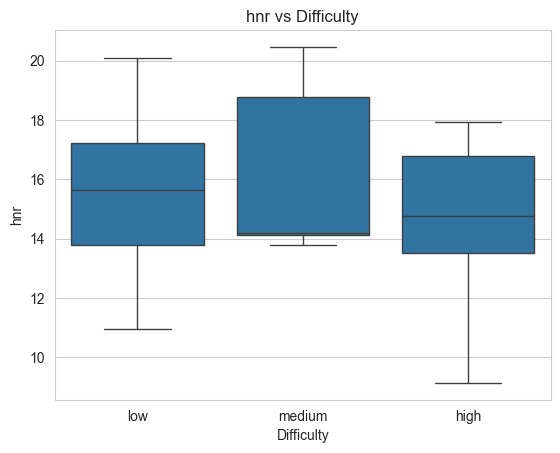

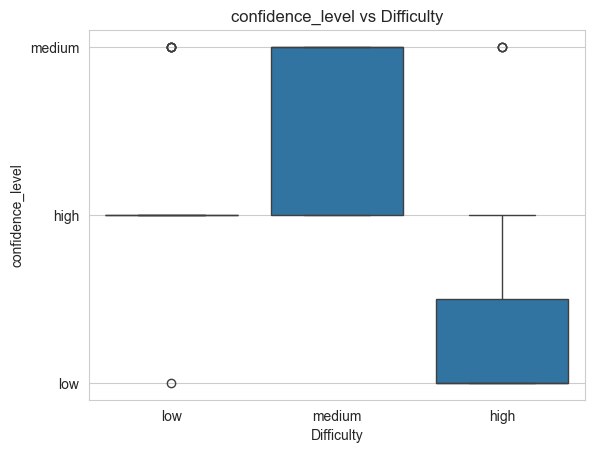

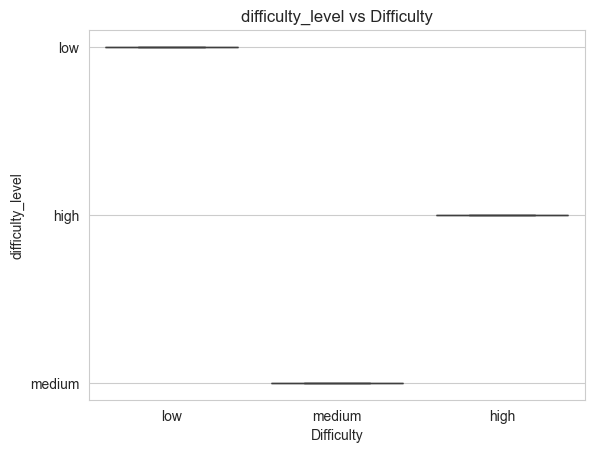

In [8]:
for feature in features:
    plt.figure()
    sns.boxplot(x="difficulty_level", y=feature, data=df, order = ["low", "medium", "high"])
    plt.title(f"{feature} vs Difficulty")
    plt.xlabel("Difficulty")
    plt.ylabel(feature)
    plt.show()

## Statistical Significance 

In [9]:
from scipy.stats import kruskal

for feature in features:
    groups = [group[feature].dropna().values 
              for _, group in df.groupby("confidence_level")]

    stat, p = kruskal(*groups)
    print(f"{feature}: p={p:.4f}")

clue_word_frequency: p=0.7124
duration: p=0.0007
clue_latency: p=0.0113
clue_number_latency: p=0.1825
speech_rate: p=0.2059
speech_ratio: p=0.3109
articulation_rate: p=0.6644
pause_count: p=0.0651
pause_mean: p=0.0948
pause_max: p=0.0373
pause_before_clue: p=0.1153
pause_mid_speech: p=0.0145
filler_count: p=0.8272
repetition_count: p=0.1703
disfluency: p=0.5780
verbal_hesitation_count: p=0.0341
meta_comment_presence: p=0.0056
pitch_mean: p=0.3738
pitch_std: p=0.8824
pitch_slope: p=0.5494
pitch_rise_end: p=0.1682
pitch_range: p=0.8404
pitch_p25: p=0.3367
pitch_p75: p=0.5152
mfcc_1_mean: p=0.2517
mfcc_1_std: p=0.7172
mfcc_2_mean: p=0.0445
mfcc_2_std: p=0.5721
mfcc_3_mean: p=0.5959
mfcc_3_std: p=0.2970
mfcc_4_mean: p=0.6042
mfcc_4_std: p=0.5064
mfcc_5_mean: p=0.8757
mfcc_5_std: p=0.2035
mfcc_6_mean: p=0.7983
mfcc_6_std: p=0.3114
mfcc_7_mean: p=0.5191
mfcc_7_std: p=0.2351
mfcc_8_mean: p=0.9155
mfcc_8_std: p=0.1953
mfcc_9_mean: p=0.8522
mfcc_9_std: p=0.1545
mfcc_10_mean: p=0.9619
mfcc_10_st

In [10]:
from scipy.stats import kruskal

for feature in features:
    groups = [group[feature].dropna().values 
              for _, group in df.groupby("difficulty_level")]

    stat, p = kruskal(*groups)
    print(f"{feature}: p={p:.4f}")

clue_word_frequency: p=0.9818
duration: p=0.0003
clue_latency: p=0.0212
clue_number_latency: p=0.0176
speech_rate: p=0.2322
speech_ratio: p=0.7819
articulation_rate: p=0.2965
pause_count: p=0.0260
pause_mean: p=0.5265
pause_max: p=0.2620
pause_before_clue: p=0.4243
pause_mid_speech: p=0.0503
filler_count: p=0.9523
repetition_count: p=0.2658
disfluency: p=0.3300
verbal_hesitation_count: p=0.2031
meta_comment_presence: p=0.0728
pitch_mean: p=0.0148
pitch_std: p=0.0478
pitch_slope: p=0.3210
pitch_rise_end: p=0.8351
pitch_range: p=0.2639
pitch_p25: p=0.0364
pitch_p75: p=0.0072
mfcc_1_mean: p=0.6670
mfcc_1_std: p=0.1783
mfcc_2_mean: p=0.4386
mfcc_2_std: p=0.2078
mfcc_3_mean: p=0.6821
mfcc_3_std: p=0.7624
mfcc_4_mean: p=0.9279
mfcc_4_std: p=0.8398
mfcc_5_mean: p=0.1643
mfcc_5_std: p=0.2726
mfcc_6_mean: p=0.1205
mfcc_6_std: p=0.2317
mfcc_7_mean: p=0.1088
mfcc_7_std: p=0.3652
mfcc_8_mean: p=0.0925
mfcc_8_std: p=0.4735
mfcc_9_mean: p=0.6980
mfcc_9_std: p=0.4842
mfcc_10_mean: p=0.2616
mfcc_10_st

## Correlations

In [37]:
def map_levels(x):
    if x == "low":
        return 0
    elif x == "medium":
        return 0.5
    elif x == "high":
        return 1
df["confidence_level"] = df["confidence_level"].apply(map_levels)
df["difficulty_level"] = df["difficulty_level"].apply(map_levels)

In [36]:
# Step 2: Compute Spearman correlation for all features + targets
corr_matrix = df[features + ["confidence_level", "difficulty_level"]].corr(method="spearman")

# Step 3: Select correlations for the target columns as Series
confidence_corr = corr_matrix["confidence_level"].drop(labels="confidence_level")
difficulty_corr = corr_matrix["difficulty_level"].drop(labels="difficulty_level")

# Step 4: Filter features with strong correlation (>0.5 absolute value)
top_confidence_features = confidence_corr[confidence_corr.abs() > 0.5].sort_values(ascending=False)
top_difficulty_features = difficulty_corr[difficulty_corr.abs() > 0.5].sort_values(ascending=False)

# Step 5: Display top 20
print("Top features correlated with confidence_level (>0.5):")
print(top_confidence_features.head(20))

print("\nTop features correlated with difficulty_level (>0.5):")
print(top_difficulty_features.head(20))

Top features correlated with confidence_level (>0.5):
duration           -0.522918
difficulty_level   -0.697349
Name: confidence_level, dtype: float64

Top features correlated with difficulty_level (>0.5):
duration            0.573166
energy_range        0.525323
confidence_level   -0.697349
Name: difficulty_level, dtype: float64
